In [1]:
# Import Libraries we will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print(' Requiremnts:  Data Cleaning , Preprocessing , Visualization , Feature Engineering , classifiey ')

 Requiremnts:  Data Cleaning , Preprocessing , Visualization , Feature Engineering , classifiey 


In [2]:
#read data
df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# ***Cleaning missing data***
there is no duplcated data butt we have some missing data in Age,Cabin & Embarkedd

In [8]:

df['Age']=df['Age'].fillna(df['Age'].median())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

#Cabin is not important colomn so we will drop it
df.drop('Cabin', axis=1, inplace=True)

In [9]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


# ***EDA-Visualization***

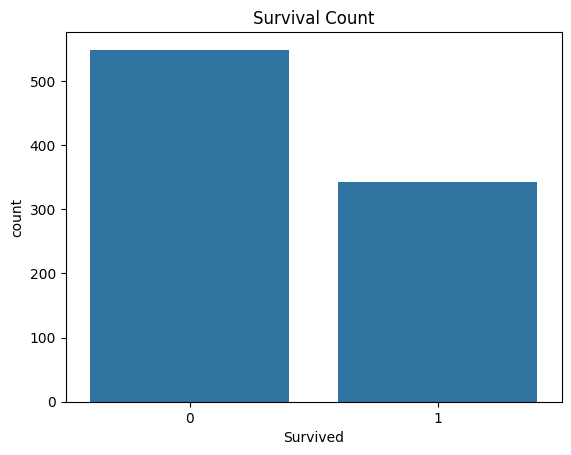

In [10]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

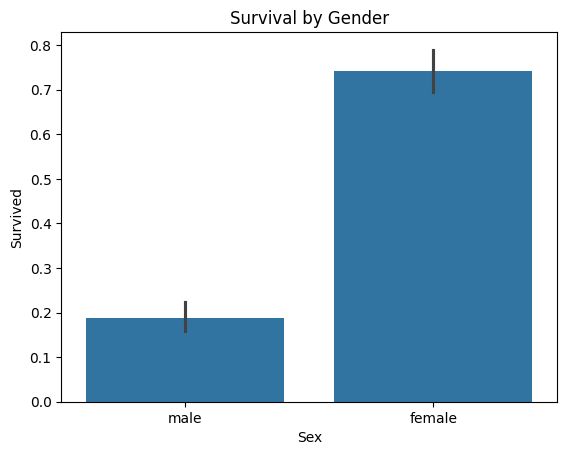

In [11]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

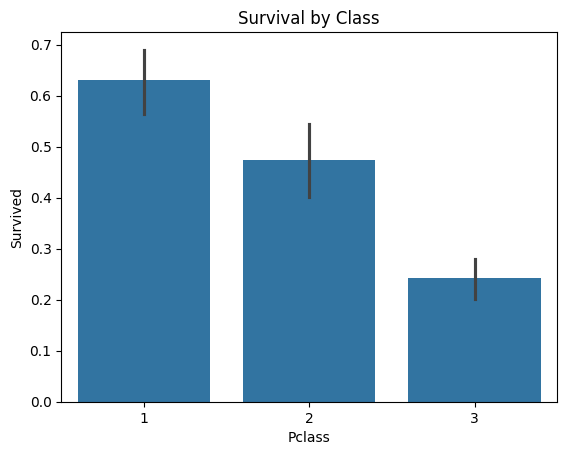

In [12]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival by Class')
plt.show()

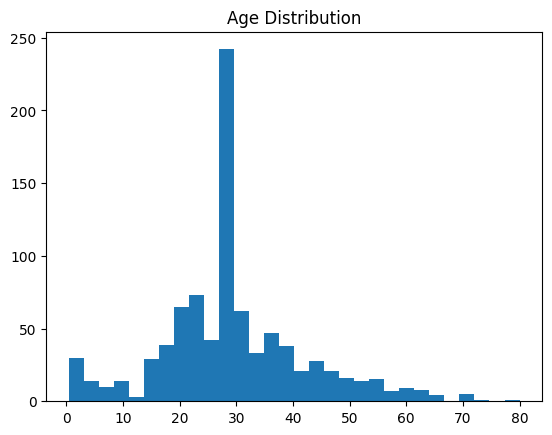

In [13]:
plt.hist(df['Age'], bins=30)
plt.title('Age Distribution')
plt.show()

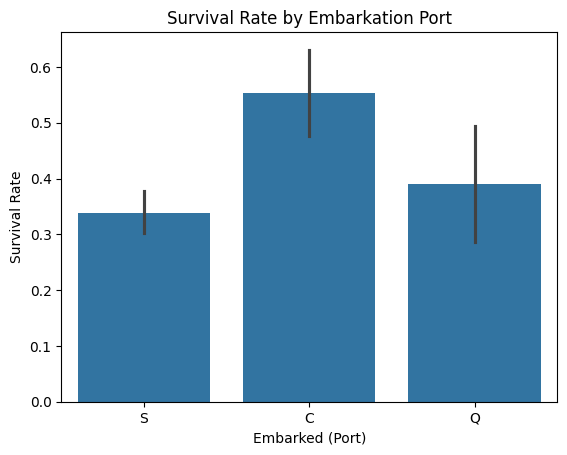

In [14]:
sns.barplot(x='Embarked', y='Survived', data=df)

plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarked (Port)')
plt.ylabel('Survival Rate')

plt.show()

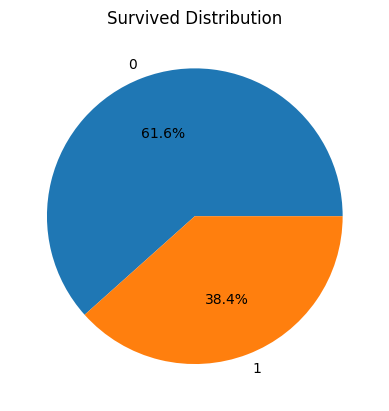

In [15]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Survived Distribution')
plt.ylabel('')

plt.show()

# ***Feature Engeneering, Encoding& Normlization***

In [16]:
#Creating new features first one is family size to get the total size of family 
#e.g. Abdelmasih's family (SipSp is siplings & Spouse) but (Parch is parentes and childrens) but at all Abdelmasih is not calculated so we adds one
#at all this step will be good for our choosed model to get to the total family members number
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [17]:
#we all know peter i think so lets genrate an encoded column of members alone like him
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [18]:
#extract title of people using regex
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

#groubing important people with VIP title i am it will affecct in serviving status
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'VIP')

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


In [20]:
#normal encoding for gender
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [21]:
#one-hot encoding for country and title if all is false so the person is classified from the dropped groub
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = pd.get_dummies(df, columns=['Title'], drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_VIP
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,0,False,True,False,False,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,0,False,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,1,False,True,True,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,0,False,True,False,False,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,1,False,True,False,False,False,True,False,False,False


In [22]:
#prepare data for model dropping unnessesary data
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [23]:
# Features(independent) & Target(dependent)

X = df.drop('Survived', axis=1)
y = df['Survived']

In [24]:
#splitting my data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ***Models***

In [25]:
#Scaling my data and trainig standerd scaler with the training data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_VIP
0,0,3,1,22.0,1,0,7.2500,2,0,False,True,False,False,False,True,False,False,False
1,1,1,0,38.0,1,0,71.2833,2,0,False,False,False,False,False,False,True,False,False
2,1,3,0,26.0,0,0,7.9250,1,1,False,True,True,False,False,False,False,False,False
3,1,1,0,35.0,1,0,53.1000,2,0,False,True,False,False,False,False,True,False,False


In [27]:
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n")
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Decision Tree
Accuracy: 0.7597765363128491
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       105
           1       0.70      0.73      0.72        74

    accuracy                           0.76       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.76      0.76      0.76       179



Random Forest
Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.

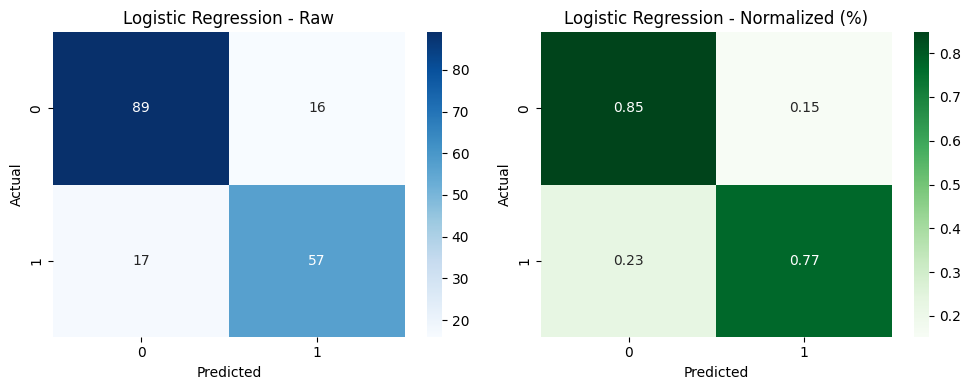

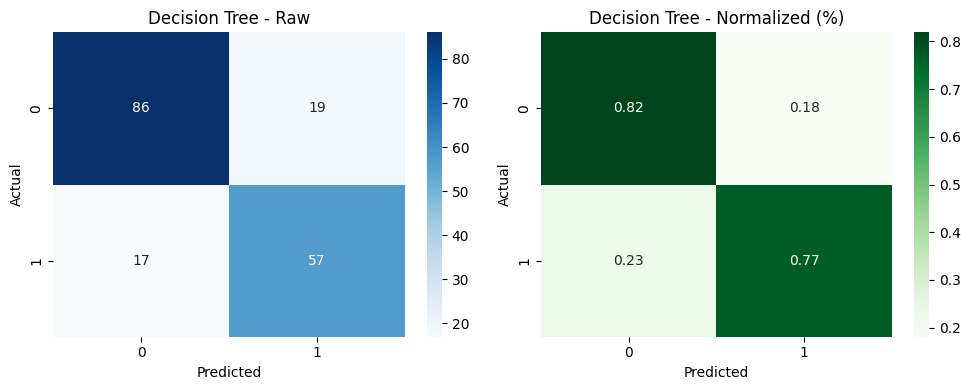

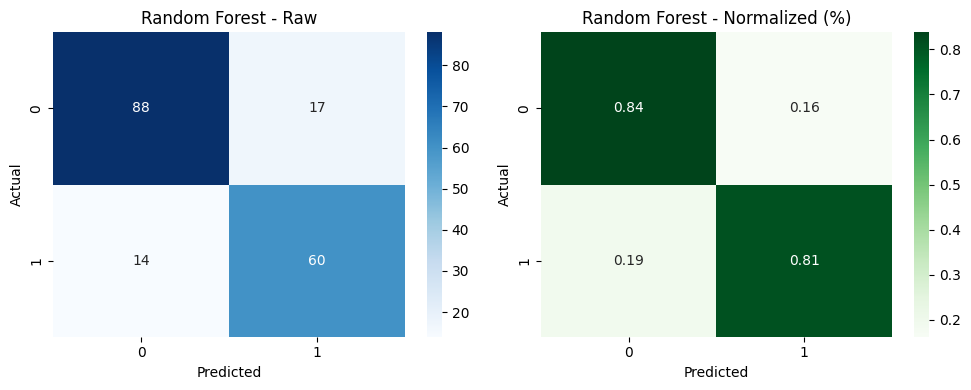

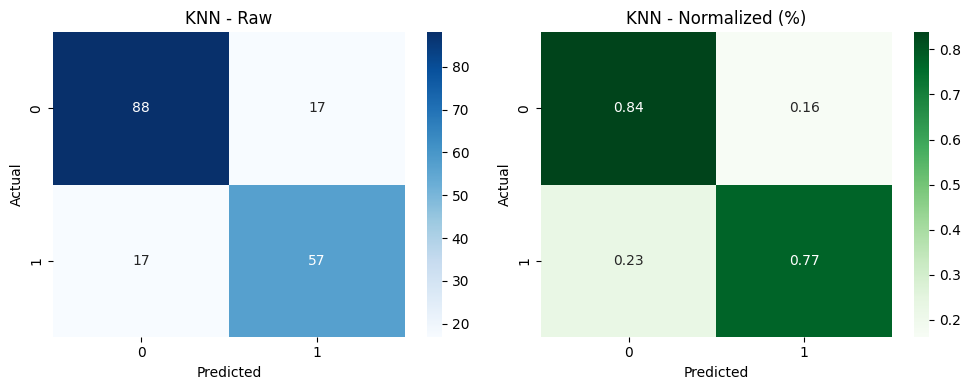

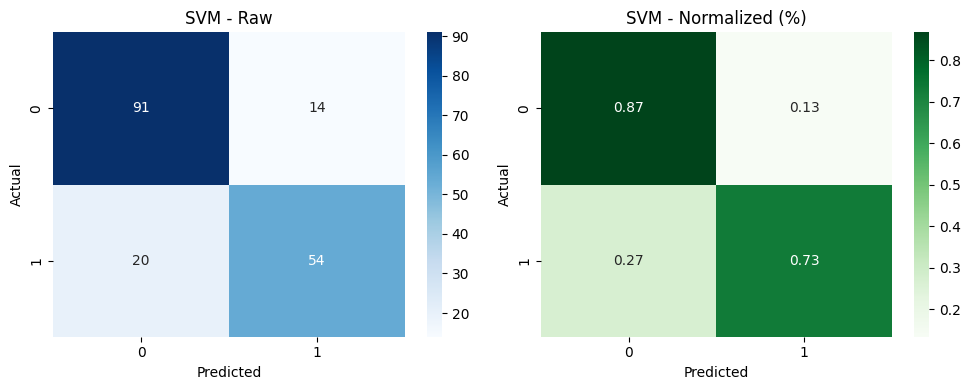

In [28]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    # normalizatoin fun for cm
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10,4))

    #Confusion Matrix
    plt.subplot(1,2,1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Raw')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Normalized CM
    plt.subplot(1,2,2)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
    plt.title(f'{name} - Normalized (%)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

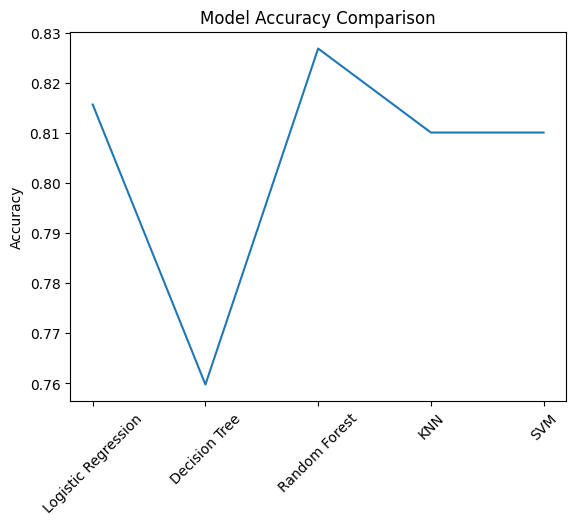

In [29]:
plt.plot(results.keys(), results.values())
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

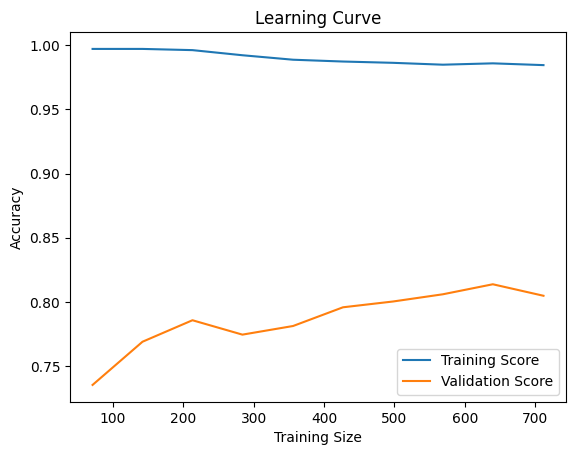

In [30]:

#LEARNING CURVE


train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(),
    X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Validation Score')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()